In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

df = pd.read_csv('semiconductor_dataset/uci-secom.csv')
df.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


Preprocessing

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def preprocessing(df):
    df = df.copy()
    df = df.drop('Time', axis=1)

    #Drop columns with too many NA
    na_columns = df.columns[df.isna().mean() >= 0.25]
    df = df.drop(na_columns, axis=1)

    #Fill na
    for column in df.columns:
        df[column] = df[column].fillna(df[column].mean())

    df['Pass/Fail'] = df['Pass/Fail'].replace({-1:"PASS", 1:"FAIL"})

    y = df['Pass/Fail']
    X = df.drop('Pass/Fail', axis=1)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=1502)

    #Scaling
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train = pd.DataFrame(scaler.transform(X_train), index=X_train.index, columns=X_train.columns)
    X_test = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)

    #Delete unique value columns
    unique_value_columns = X_train.columns[(pd.Series({column:len(X_train[column].unique()) for column in X_train.columns}) == 1)]
    X_train = X_train.drop(unique_value_columns, axis=1)
    X_test = X_test.drop(unique_value_columns, axis=1)
    
    return X_train, X_test, y_train, y_test

In [3]:
X_train, X_test, y_train, y_test = preprocessing(df)

<Axes: xlabel='Pass/Fail'>

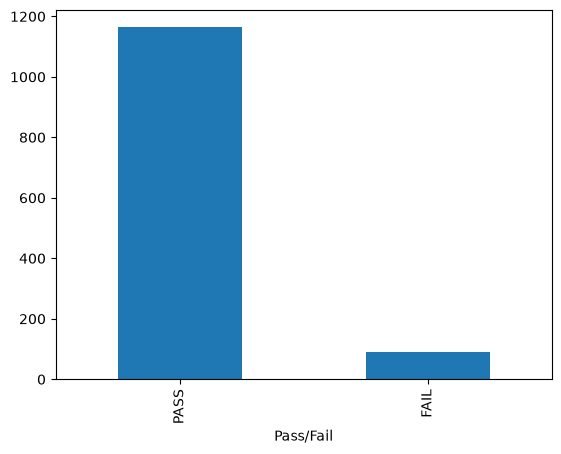

In [4]:
y_train.value_counts().plot.bar()

In [5]:
from imblearn.over_sampling import RandomOverSampler, SMOTE

sampler_ros = RandomOverSampler(random_state=15)
sampler_smote = SMOTE(random_state=15)
X_train_os, y_train_os = sampler_ros.fit_resample(X_train, y_train)
X_train_smote, y_train_smote = sampler_smote.fit_resample(X_train, y_train)

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [40]:
X_train_t, X_test_t = torch.from_numpy(X_train_smote.values).float(), torch.from_numpy(X_test.values).float()
y_dict = {'PASS':1, 'FAIL':0}
y_train_n, y_test_n = pd.to_numeric(y_train_smote.replace(y_dict)), pd.to_numeric(y_test.replace(y_dict))
y_train_t, y_test_t = torch.from_numpy(y_train_n.values).float().unsqueeze(1), torch.from_numpy(y_test_n.values).float().unsqueeze(1)

In [41]:
X_train_t.shape, y_train_t.shape, X_train_t.dtype, y_train_t.dtype

(torch.Size([2328, 442]), torch.Size([2328, 1]), torch.float32, torch.float32)

In [42]:
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [82]:
class SemconModel(nn.Module):
    def __init__(self):
        super(SemconModel, self).__init__()

        self.fc1 = nn.Linear(442, 512)
        self.fc2 = nn.Linear(512, 2048)
        self.fc3 = nn.Linear(2048, 256)
        self.fc4 = nn.Linear(256, 64)
        self.fcl = nn.Linear(64, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = F.sigmoid(self.fcl(x))
        return x

In [83]:
model = SemconModel()

In [84]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [85]:
epochs = 20

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()

        preds = model(x_batch)
        loss = criterion(preds, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f'Epoch {epoch+1}: Loss was {running_loss / len(train_loader)}')

Epoch 1: Loss was 0.31049744988957495
Epoch 2: Loss was 0.04392795946468178
Epoch 3: Loss was 0.018716101345190722
Epoch 4: Loss was 0.0016778611408557332
Epoch 5: Loss was 2.2379177749664377e-05
Epoch 6: Loss was 1.230763891352618e-05
Epoch 7: Loss was 8.954221530526934e-06
Epoch 8: Loss was 7.017921045340787e-06
Epoch 9: Loss was 5.620812921367908e-06
Epoch 10: Loss was 4.606313134274063e-06
Epoch 11: Loss was 3.845502344076572e-06
Epoch 12: Loss was 3.292572916097613e-06
Epoch 13: Loss was 2.7933992849857657e-06
Epoch 14: Loss was 2.400500675776908e-06
Epoch 15: Loss was 2.0857081149063572e-06
Epoch 16: Loss was 1.8409392590559048e-06
Epoch 17: Loss was 1.6124472506187306e-06
Epoch 18: Loss was 1.4399255821911396e-06
Epoch 19: Loss was 1.2753644831970215e-06
Epoch 20: Loss was 1.1360132014625091e-06


In [86]:
with torch.inference_mode(): #torch.inference_mode()
    model.eval()
    preds = model(X_test_t)
    loss = criterion(preds, y_test_t).item()

    accuracy = ((preds >= 0.5) == y_test_t).float().mean().item()

In [87]:
accuracy

0.9299362897872925